In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error
from scipy.optimize import curve_fit


In [78]:
df= pd.read_csv('resource_pressure_data.csv')

In [79]:
df = df[df['cpu_avg'] > 0].copy()
#df['failure_rate'] = df['request_failed_count'] / df['request_sent_count']
#df['cpu_allocated']= df['pod_count']*4 #m6i.xlarge instance has 4 vcpus
df['resource_pressure'] = df['cpu_avg'] / (df['pod_count']*100 )  # 2 vCPUs per node

In [80]:
df

,pod_count,request_sent_count,request_failed_count,failure_rate,cpu_avg,memory_avg,user_count,request_interval,test_duration,resource_pressure
0,1,25,0,0.000000,84.468750,60.938381,5,6,30,0.844687
1,1,20,1,5.000000,42.640000,55.868952,4,6,30,0.426400
2,1,15,3,20.000000,32.253333,55.975493,3,6,30,0.322533
3,1,10,0,0.000000,57.733333,56.073872,2,6,30,0.577333
4,2,25,8,32.000000,65.397500,57.115649,5,6,30,0.326988
5,2,20,6,30.000000,67.341667,57.947954,4,6,30,0.336708
6,2,15,1,6.666667,77.348333,58.185893,3,6,30,0.386742
7,2,10,0,0.000000,70.043333,58.123627,2,6,30,0.350217
8,3,25,4,16.000000,81.476667,59.494115,5,6,30,0.271589
9,3,20,14,70.000000,108.291667,60.541115,4,6,30,0.360972


In [81]:
X = df[['resource_pressure']].values
y = df['failure_rate'].values

In [82]:
from sklearn.ensemble import IsolationForest

#Z SCORE

# data_points = np.hstack((X, y.reshape(-1, 1)))

# # Calculate z-scores
# z_scores = np.abs(zscore(data_points))

# # Keep points where both X and y z-scores < 3 (typical threshold)
# mask = (z_scores < 3).all(axis=1)

#ISOLATION FOREST
# iso = IsolationForest(contamination=0.1)  # Adjust contamination level
# outliers = iso.fit_predict(np.hstack((X, y.reshape(-1,1))))
# mask = outliers == 1  # 1 means inlier


#REMOVING X POINTS
# threshold = 0.6
# mask = X.flatten() <= threshold

# X_filtered = X[mask]
# y_filtered = y[mask]
# X=X_filtered
# y=y_filtered

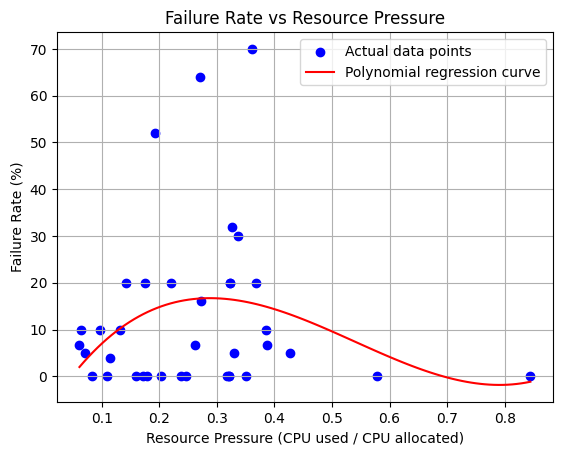

In [83]:
degree = 3
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

# y_fit = model.predict(X_poly) 
# plt.scatter(X, y, color='blue', label='Actual data points')  # Original data
# plt.plot(X, y_fit, color='red', linestyle='--', marker='o', label='Model predictions')  # Model fit on actual points
# plt.xlabel('Resource Pressure (CPU used / CPU allocated)')
# plt.ylabel('Failure Rate (%)')
# plt.title('Failure Rate vs Resource Pressure')
# plt.legend()
# plt.grid(True)
# plt.show()

x_smooth = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_smooth_poly = poly.transform(x_smooth)
y_smooth = model.predict(x_smooth_poly)

# Plot
plt.scatter(X, y, color='blue', label='Actual data points')  # Original data
plt.plot(x_smooth, y_smooth, color='red', label='Polynomial regression curve')  # Smooth curve
plt.xlabel('Resource Pressure (CPU used / CPU allocated)')
plt.ylabel('Failure Rate (%)')
plt.title('Failure Rate vs Resource Pressure')
plt.legend()
plt.grid(True)
plt.show()

In [87]:
def modelFunc(coefficients,x):
    degree=len(coefficients)
    ans=0
    for i in range(0,degree):
        ans= ans + (coefficients[i]*(x**i))
    return ans

full_coefficients = np.append(model.intercept_, model.coef_[1:])  # skip coef_[0] (it’s for the bias term which intercept_ handles)
print(full_coefficients)
modelFunc(full_coefficients,0.205)

[  -8.49894587  199.2504812  -471.9632605   291.65156642]


np.float64(15.025761458581043)

In [84]:
coefficients = model.coef_
intercept = model.intercept_
coefficients,intercept

(array([   0.        ,  199.2504812 , -471.9632605 ,  291.65156642]),
 np.float64(-8.498945865272546))